# Customer Segmentation using PCA and K-Means Clustering

This section focuses on identifying groups of customers with similar purchasing behaviour. Principal Component Analysis (PCA) is first used to reduce the dimensionality of the customer-purchasing data, followed by K-Means clustering to identify distinct customer segments.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import os
print('\n'.join(os.listdir()))

.config
orders.csv
aisles.csv
departments.csv
order_products__train.csv
products.csv
order_products__prior.csv
sample_data


## Preparing the Customer-Purchasing Data

The order, product, aisle, and customer information are combined to obtain a dataset that links each customer to the aisles in which they make purchases. This provides the basis for constructing a customer-level representation of purchasing behaviour.

In [ ]:
orders = pd.read_csv('orders.csv')
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1.0,2.0,8.0,NaN
1,2398795,1,prior,2.0,3.0,7.0,15.0
2,473747,1,prior,3.0,3.0,12.0,21.0
3,2254736,1,prior,4.0,4.0,7.0,29.0
4,431534,1,prior,5.0,4.0,15.0,28.0


In [ ]:
prior = pd.read_csv('order_products__prior.csv')
prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120.0,1.0,1.0
1,2,28985.0,2.0,1.0
2,2,9327.0,3.0,0.0
3,2,45918.0,4.0,1.0
4,2,30035.0,5.0,0.0


In [ ]:
train = pd.read_csv('order_products__train.csv')
train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [ ]:
order_prior = pd.merge(prior,orders,on=['order_id','order_id'])
order_prior = order_prior.sort_values(by=['user_id','order_id'])
order_prior.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
2582424,431534,196.0,1.0,1.0,1,prior,5.0,4.0,15.0,28.0
2582425,431534,12427.0,2.0,1.0,1,prior,5.0,4.0,15.0,28.0
2582426,431534,10258.0,3.0,1.0,1,prior,5.0,4.0,15.0,28.0
2582427,431534,25133.0,4.0,1.0,1,prior,5.0,4.0,15.0,28.0
2582428,431534,10326.0,5.0,0.0,1,prior,5.0,4.0,15.0,28.0


In [ ]:
products = pd.read_csv('products.csv')
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
aisles = pd.read_csv('aisles.csv')
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [ ]:
print(aisles.shape)

(134, 2)


In [ ]:
# Read and optimize orders
orders = pd.read_csv('orders.csv', dtype={
    'order_id': 'int32',
    'user_id': 'int32',
    'order_number': 'int16',
    'order_dow': 'int8',
    'order_hour_of_day': 'int8',
    'days_since_prior_order': 'float32'
})

# Read and optimize products
products = pd.read_csv('products.csv', dtype={
    'product_id': 'int32',
    'product_name': 'category',
    'aisle_id': 'int16',
    'department_id': 'int8'
})

# Read and optimize aisles
aisles = pd.read_csv('aisles.csv', dtype={
    'aisle_id': 'int16',
    'aisle': 'category'
})

In [ ]:
import os

dtypes_prior = {
    'order_id': 'int32',
    'product_id': 'int32',
    'add_to_cart_order': 'int16',
    'reordered': 'int8'
}

chunksize = 500_000
output_file = 'mt_merged.csv'

if os.path.exists(output_file):
    os.remove(output_file)

write_header = True
chunk_num = 0

for chunk in pd.read_csv('order_products__prior.csv', dtype=dtypes_prior, chunksize=chunksize):
    temp = pd.merge(chunk, products, on='product_id', how='left')
    temp_orders = orders[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day']].copy()
    temp = pd.merge(temp, temp_orders, on='order_id', how='left')
    temp = pd.merge(temp, aisles, on='aisle_id', how='left')

    temp.to_csv(output_file, mode='a', index=False, header=write_header)
    write_header = False
    chunk_num += 1
    print(f"✅ Processed chunk {chunk_num}")

print("🎉 All chunks processed and saved to 'mt_merged.csv'")

✅ Processed chunk 1
✅ Processed chunk 2
✅ Processed chunk 3
✅ Processed chunk 4
✅ Processed chunk 5
✅ Processed chunk 6
✅ Processed chunk 7
✅ Processed chunk 8
✅ Processed chunk 9
✅ Processed chunk 10
✅ Processed chunk 11
✅ Processed chunk 12
✅ Processed chunk 13
✅ Processed chunk 14
✅ Processed chunk 15
✅ Processed chunk 16
✅ Processed chunk 17
✅ Processed chunk 18
✅ Processed chunk 19
✅ Processed chunk 20
✅ Processed chunk 21
✅ Processed chunk 22
✅ Processed chunk 23
✅ Processed chunk 24
✅ Processed chunk 25
🎉 All chunks processed and saved to 'mt_merged.csv'


In [ ]:
dtypes_mt = {
    'order_id': 'int32',
    'product_id': 'int32',
    'add_to_cart_order': 'int16',
    'reordered': 'int8',
    'product_name': 'category',
    'aisle_id': 'int16',
    'department_id': 'int8',
    'user_id': 'int32',
    'order_number': 'int16',
    'order_dow': 'int8',
    'order_hour_of_day': 'int8',
    'aisle': 'category'
}

chunksize = 500_000

product_name_counts = pd.Series(dtype='int64')
aisle_counts = pd.Series(dtype='int64')
unique_products = set()

for i, chunk in enumerate(pd.read_csv('mt_merged.csv', dtype=dtypes_mt, chunksize=chunksize)):
    product_name_counts = product_name_counts.add(chunk['product_name'].value_counts(), fill_value=0)
    aisle_counts = aisle_counts.add(chunk['aisle'].value_counts(), fill_value=0)
    unique_products.update(chunk['product_name'].unique())
    print(f"✅ Processed chunk {i+1}")

product_name_counts = product_name_counts.sort_values(ascending=False)
aisle_counts = aisle_counts.sort_values(ascending=False)

print("🎉 All chunks processed")

✅ Processed chunk 1
✅ Processed chunk 2
✅ Processed chunk 3
✅ Processed chunk 4
✅ Processed chunk 5
✅ Processed chunk 6
✅ Processed chunk 7
✅ Processed chunk 8
✅ Processed chunk 9
✅ Processed chunk 10
✅ Processed chunk 11
✅ Processed chunk 12
✅ Processed chunk 13
✅ Processed chunk 14
✅ Processed chunk 15
✅ Processed chunk 16
✅ Processed chunk 17
✅ Processed chunk 18
✅ Processed chunk 19
✅ Processed chunk 20
✅ Processed chunk 21
✅ Processed chunk 22
✅ Processed chunk 23
✅ Processed chunk 24
✅ Processed chunk 25
🎉 All chunks processed


In [ ]:
pd.read_csv('mt_merged.csv', dtype=dtypes_mt, nrows=5)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,order_number,order_dow,order_hour_of_day,aisle
0,2,33120,1,1,Organic Egg Whites,86,16,202279,3,5,9,eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,202279,3,5,9,fresh vegetables
2,2,9327,3,0,Garlic Powder,104,13,202279,3,5,9,spices seasonings
3,2,45918,4,1,Coconut Butter,19,13,202279,3,5,9,oils vinegars
4,2,30035,5,0,Natural Sweetener,17,13,202279,3,5,9,baking ingredients


In [ ]:
product_name_counts.head(10)

,0
product_name,
Banana,180202.0
Bag of Organic Bananas,144350.0
Organic Strawberries,101070.0
Organic Baby Spinach,91464.0
Organic Hass Avocado,81100.0
Organic Avocado,66777.0
Large Lemon,57907.0
Strawberries,54190.0
Limes,53215.0


In [ ]:
len(unique_products)

48938

In [ ]:
len(aisle_counts)

134

In [ ]:
aisle_counts.head(10)

,0
aisle,
fresh fruits,1385003.0
fresh vegetables,1297713.0
packaged vegetables fruits,671292.0
yogurt,552531.0
packaged cheese,372063.0
milk,339078.0
water seltzer sparkling water,318967.0
chips pretzels,275140.0
soy lactosefree,242848.0


## Constructing the Customer-Aisle Matrix

To represent customer purchasing behaviour, we construct a matrix in which each row corresponds to a customer and each column corresponds to an aisle. The entries represent the number of purchases made by a customer from each aisle.

This creates a high-dimensional representation of customer purchasing behaviour, which will subsequently be reduced using PCA.

In [ ]:
import gc

chunksize = 100_000
cust_prod = None

usecols = ['user_id', 'aisle']
dtypes_cp = {'user_id': 'int32', 'aisle': 'category'}

for i, chunk in enumerate(pd.read_csv('mt_merged.csv', usecols=usecols, dtype=dtypes_cp, chunksize=chunksize)):
    ct = pd.crosstab(chunk['user_id'], chunk['aisle'])

    if cust_prod is None:
        cust_prod = ct
    else:
        cust_prod = cust_prod.add(ct, fill_value=0)

    print(f"Processed chunk {i+1}")
    del chunk, ct

cust_prod = cust_prod.astype(pd.SparseDtype("int", fill_value=0))
gc.collect()
cust_prod.head(10)

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Processed chunk 32
Processed chunk 33
Processed chunk 34
Processed chunk 35
Processed chunk 36
Processed chunk 37
Processed chunk 38
Processed chunk 39
Processed chunk 40
Processed chunk 41
Processed chunk 42
Processed chunk 43
Processed chunk 44
Processed chunk 45
Processed chunk 46
Processed chunk 47
Processed chunk 48
Processed chunk 49
Processed chunk 50
Processed chunk 51
Processed chunk 52
Processed chunk 53
Pr

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,14
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
8,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,5,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,5


The resulting matrix contains 194,319 customers and 134 aisle-level purchasing variables. Since the number of variables is relatively large, dimensionality reduction is useful before applying clustering.

In [ ]:
cust_prod.shape

(194319, 134)

## Principal Component Analysis (PCA)

PCA is used to reduce the dimensionality of the customer-purchasing data while retaining as much of the variation in the original data as possible.

Each principal component is a linear combination of the original aisle-level variables. The first principal component captures the largest possible amount of variation, the second captures the largest remaining variation subject to being orthogonal to the first, and so on.

### Choosing the Number of Principal Components

We examine the proportion of total variance explained by the principal components. The cumulative explained variance helps determine how many components are needed to obtain a useful lower-dimensional representation of the original data.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA().fit(cust_prod)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

for threshold in [0.70, 0.80, 0.90, 0.95]:
    n_needed = np.argmax(cumulative >= threshold) + 1
    print(f"{int(threshold*100)}% variance needs {n_needed} components")

print(f"\n6 components explain {cumulative[5]*100:.1f}% of total variance")

print("\nCumulative variance by component:")
for i in range(15):
    print(f"PC{i+1}: {cumulative[i]*100:.1f}%")

70% variance needs 7 components
80% variance needs 14 components
90% variance needs 30 components
95% variance needs 48 components

6 components explain 69.8% of total variance

Cumulative variance by component:
PC1: 46.1%
PC2: 55.6%
PC3: 60.9%
PC4: 64.4%
PC5: 67.4%
PC6: 69.8%
PC7: 71.8%
PC8: 73.7%
PC9: 75.1%
PC10: 76.5%
PC11: 77.7%
PC12: 78.8%
PC13: 79.9%
PC14: 80.9%
PC15: 81.8%


The first six principal components explain approximately 69.8% of the total variance. These six components therefore provide a substantially lower-dimensional representation of the original 134-dimensional purchasing data while retaining a large proportion of its variation.

### Scree Plot

The scree plot visualises the amount of variance explained by each principal component. It provides a visual way of assessing how quickly the contribution of additional components decreases.

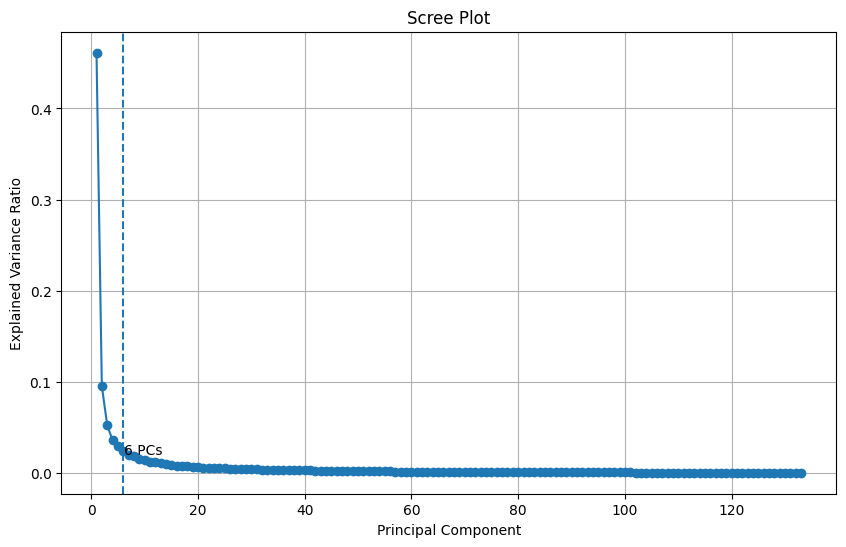

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained) + 1),
    explained,
    marker='o'
)

# Mark the 6th component
plt.axvline(x=6, linestyle='--')
plt.text(6.2, explained[5], '6 PCs', va='center')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')

plt.grid(True)
plt.show()

The first few components account for a relatively large proportion of the variation, while the contribution of subsequent components becomes progressively smaller. We therefore retain the first six components for further analysis.

## Transforming the Data into Principal Component Space

We now retain the first six principal components and transform each customer's original 134-dimensional purchasing profile into a six-dimensional representation. Each customer is therefore represented by six principal component scores instead of the original 134 aisle-level variables.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=6)
pca.fit(cust_prod)
pca_samples = pca.transform(cust_prod)

## Interpreting the Principal Components

To understand what each principal component represents, we examine its loadings on the original aisle-level variables. A larger absolute loading indicates that the corresponding aisle contributes more strongly to that principal component.

In [ ]:
ps = pd.DataFrame(pca_samples)
ps.head()

,0,1,2,3,4,5
0,-8.838620,-1.016452,-2.585668,-1.052402,-0.015737,-0.071080
1,1.486663,-12.538806,1.782333,-5.843099,-2.045399,-0.167812
2,-8.443540,-0.770875,-2.160524,0.068686,-0.104394,-0.437680
3,-10.563175,0.045371,-1.474314,-1.287180,-0.079083,0.277786
4,-8.996624,1.147773,0.374495,-1.450301,0.385448,-0.669076


In [ ]:
# ============================================================
# STEP 1: Examine the PCA loadings
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(1, 7)],
    index=cust_prod.columns
)

display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6
aisle,,,,,,
air fresheners candles,0.000513,-0.001314,0.001183,0.006544,-0.000542,-0.002580
asian foods,0.020810,0.008613,0.014697,0.028177,-0.003622,-0.015500
baby accessories,0.001303,-0.000630,0.000371,0.002158,0.004210,0.000976
baby bath body care,0.001094,-0.000685,0.000261,0.001699,0.003336,0.000122
baby food formula,0.071911,-0.079477,0.008923,0.054287,0.899875,0.373541
...,...,...,...,...,...,...
trash bags liners,0.001937,-0.002385,0.001462,0.009065,0.001598,-0.002592
vitamins supplements,0.005458,-0.002525,0.000795,0.011293,-0.000964,-0.000321
water seltzer sparkling water,0.074297,-0.149253,0.068231,0.510010,-0.256319,0.623381


### Major Contributors to Each Principal Component

For each principal component, we identify the variables with the largest absolute loadings. This allows us to interpret the types of purchasing behaviour represented by the different components.

In [ ]:
# ============================================================
# STEP 2: Find the 10 variables with the largest loadings
#         for each of the 6 principal components
# ============================================================

for pc in loadings.columns:
    print(f"\nTop 10 variables contributing to {pc}:")
    display(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )



Top 10 variables contributing to PC1:


,PC1
aisle,
fresh fruits,0.625869
fresh vegetables,0.601980
packaged vegetables fruits,0.272184
yogurt,0.222328
packaged cheese,0.129754
milk,0.121769
soy lactosefree,0.084473
chips pretzels,0.076310
bread,0.075643



Top 10 variables contributing to PC2:


,PC2
aisle,
fresh vegetables,0.679163
yogurt,0.542126
fresh fruits,0.305122
water seltzer sparkling water,0.149253
energy granola bars,0.137461
milk,0.131282
chips pretzels,0.117047
refrigerated,0.095637
packaged cheese,0.085261



Top 10 variables contributing to PC3:


...

,PC4
aisle,
water seltzer sparkling water,0.510010
yogurt,0.414382
chips pretzels,0.315109
fresh fruits,0.258853
energy granola bars,0.215378
refrigerated,0.212171
packaged cheese,0.177896
packaged vegetables fruits,0.157798
soft drinks,0.152856



Top 10 variables contributing to PC5:


,PC5
aisle,
baby food formula,0.899875
water seltzer sparkling water,0.256319
packaged cheese,0.146652
milk,0.137030
energy granola bars,0.113835
fresh fruits,0.107491
packaged vegetables fruits,0.091859
refrigerated,0.077569
yogurt,0.072783



Top 10 variables contributing to PC6:


,PC6
aisle,
water seltzer sparkling water,0.623381
packaged vegetables fruits,0.434269
baby food formula,0.373541
packaged cheese,0.263121
chips pretzels,0.145235
bread,0.139050
fresh vegetables,0.135553
fresh fruits,0.133821
milk,0.122988


The principal components are associated with different combinations of purchasing categories. For example, PC1 has particularly large contributions from fresh fruits and fresh vegetables, while PC5 is strongly associated with the baby food and formula aisle. Thus, the components can be viewed as capturing different dimensions of customer purchasing behaviour.

## Exploring the Principal Component Space

Since six principal components generate several possible two-dimensional combinations, we visualise all pairwise combinations of the six components. The objective is to examine whether some pairs reveal clearer patterns or separation among customers than others.

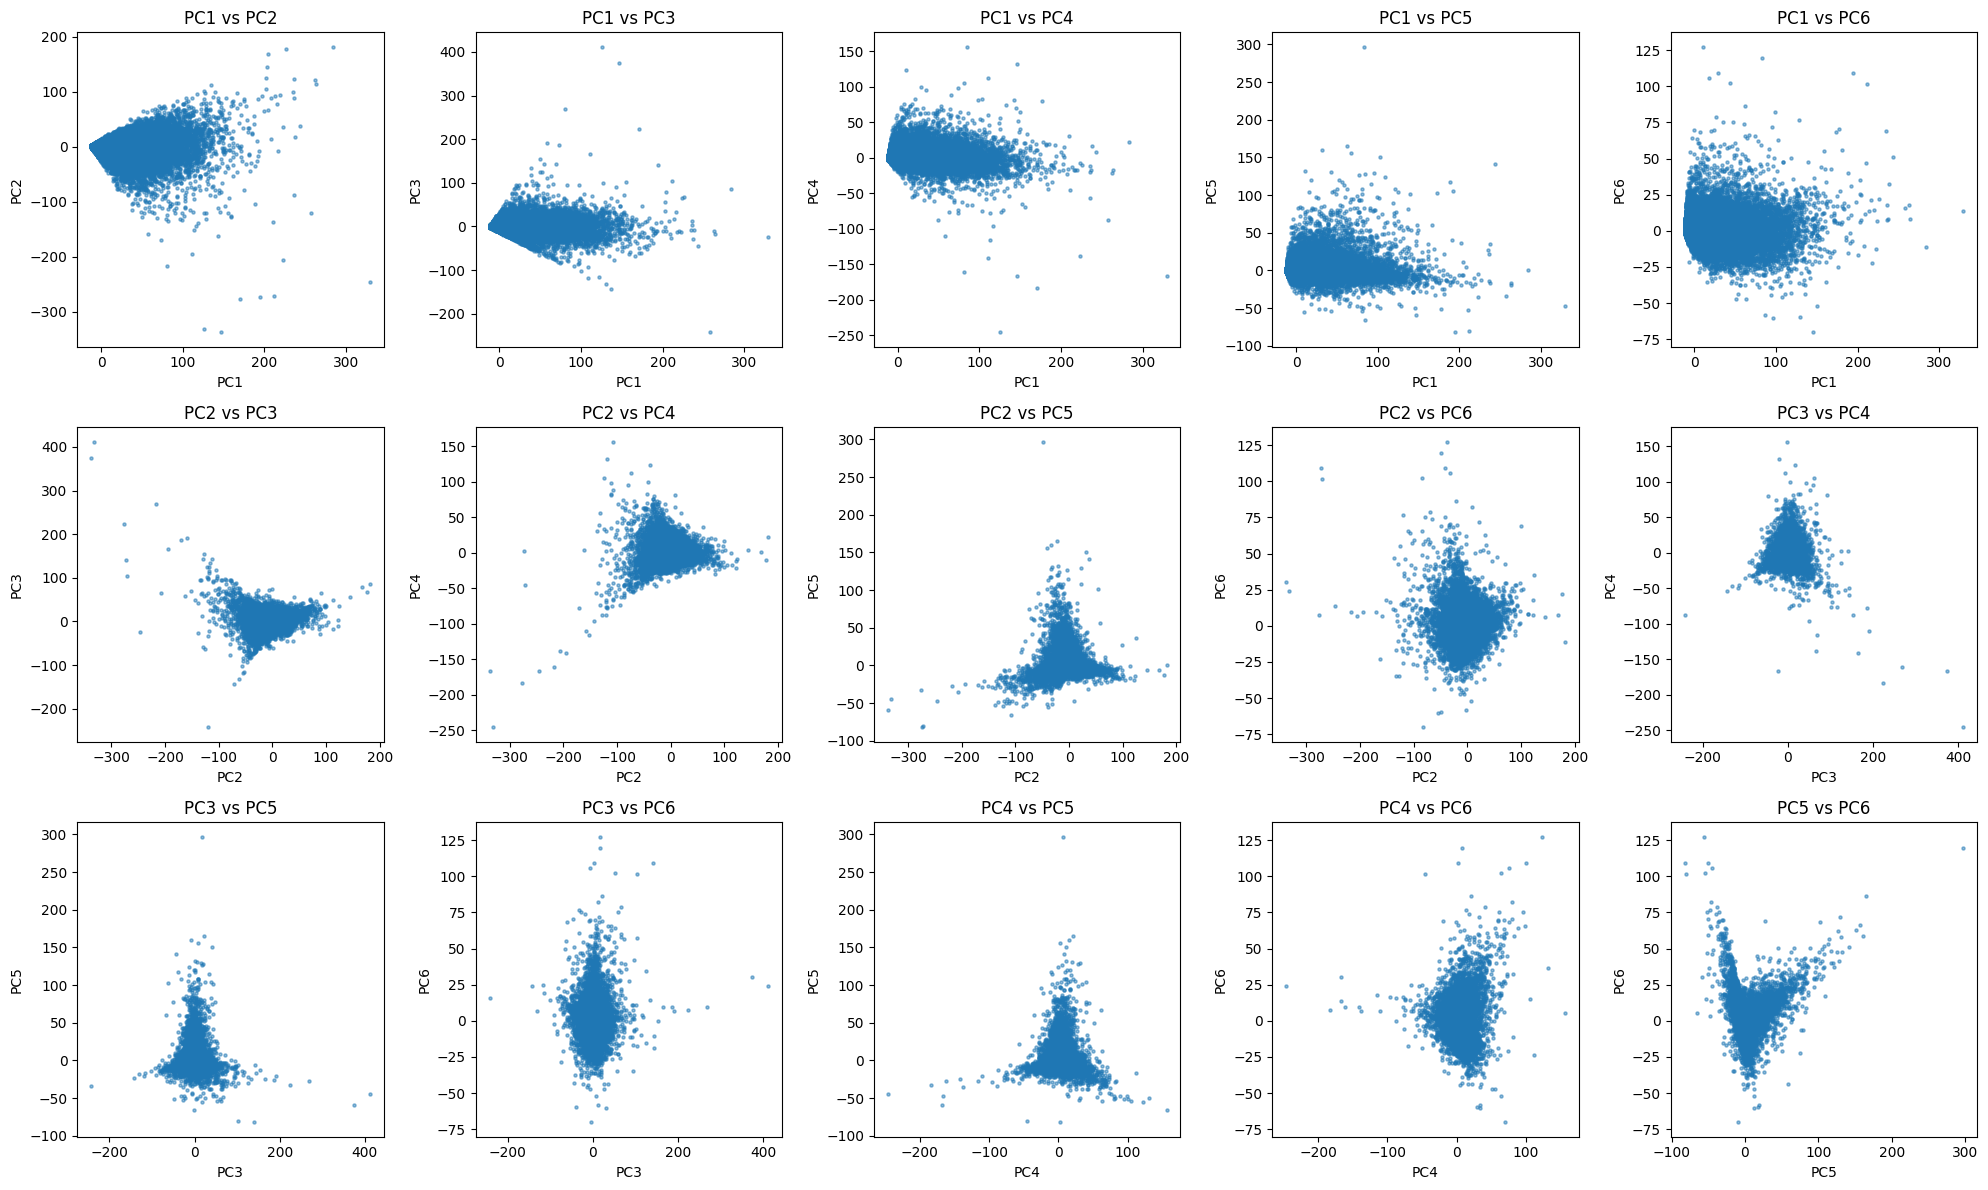

In [ ]:
# ============================================================
# STEP 3: Plot all possible pairs of the 6 PCs
# ============================================================

import itertools
import matplotlib.pyplot as plt

pairs = list(itertools.combinations(range(6), 2))

fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for ax, (i, j) in zip(axes.flatten(), pairs):
    ax.scatter(
        pca_samples[:, i],
        pca_samples[:, j],
        s=5,
        alpha=0.5
    )

    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{j+1}')
    ax.set_title(f'PC{i+1} vs PC{j+1}')

plt.tight_layout()
plt.show()

The pairwise plots provide a visual assessment of the structure of the customer data in the reduced-dimensional space and help identify suitable dimensions for subsequent clustering.

## Selecting Dimensions for K-Means Clustering

For the clustering analysis, we use PC2 and PC5 as the two dimensions representing each customer. This reduces the clustering problem to a two-dimensional space, making the resulting customer segments easier to visualise and interpret.

,PC Pair,Variance Explained (%)
0,PC1 + PC2,55.621947
1,PC1 + PC3,51.370778
2,PC1 + PC4,49.684856
3,PC1 + PC5,49.109086
4,PC1 + PC6,48.533041
5,PC2 + PC3,14.751605
6,PC2 + PC4,13.065683
7,PC2 + PC5,12.489913
8,PC2 + PC6,11.913867
9,PC3 + PC4,8.814514



PC2 + PC5 explain 12.49% of total variance.

Top loading variables for each PC:


PC1:


,PC1
aisle,
fresh fruits,0.625869
fresh vegetables,0.601980
packaged vegetables fruits,0.272184
yogurt,0.222328
packaged cheese,0.129754



PC2:


,PC2
aisle,
fresh vegetables,0.679163
yogurt,0.542126
fresh fruits,0.305122
water seltzer sparkling water,0.149253
energy granola bars,0.137461


...

,PC4
aisle,
water seltzer sparkling water,0.510010
yogurt,0.414382
chips pretzels,0.315109
fresh fruits,0.258853
energy granola bars,0.215378



PC5:


,PC5
aisle,
baby food formula,0.899875
water seltzer sparkling water,0.256319
packaged cheese,0.146652
milk,0.137030
energy granola bars,0.113835



PC6:


,PC6
aisle,
water seltzer sparkling water,0.623381
packaged vegetables fruits,0.434269
baby food formula,0.373541
packaged cheese,0.263121
chips pretzels,0.145235


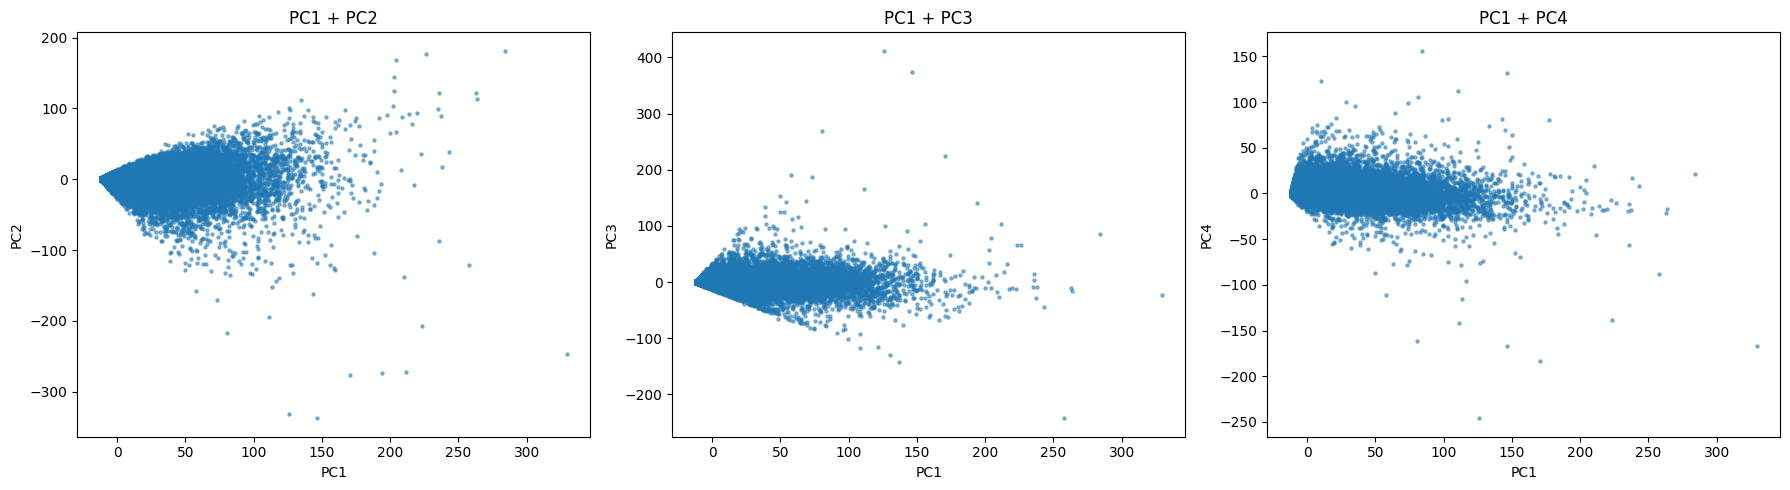

In [ ]:
# ============================================================
# STEP 1: Calculate how much variance each possible PC pair
#         explains
# ============================================================

import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# explained_variance_ratio for the 6 PCs
explained_6 = pca.explained_variance_ratio_

pairs = list(itertools.combinations(range(6), 2))

pair_results = []

for i, j in pairs:
    pair_results.append({
        'PC1_index': i,
        'PC2_index': j,
        'PC Pair': f'PC{i+1} + PC{j+1}',
        'Variance Explained (%)':
            (explained_6[i] + explained_6[j]) * 100
    })

pair_variance = pd.DataFrame(pair_results)

pair_variance = pair_variance.sort_values(
    'Variance Explained (%)',
    ascending=False
).reset_index(drop=True)

display(
    pair_variance[
        ['PC Pair', 'Variance Explained (%)']
    ]
)


# ============================================================
# STEP 2: Look specifically at PC2 + PC5
# ============================================================

pc2_pc5_variance = (
    explained_6[1] + explained_6[4]
) * 100

print(
    f"\nPC2 + PC5 explain "
    f"{pc2_pc5_variance:.2f}% of total variance."
)


# ============================================================
# STEP 3: Compare the strongest loading variables for
#         each possible PC used in the pair
# ============================================================

print("\nTop loading variables for each PC:\n")

for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']:
    print(f"\n{pc}:")
    display(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )


# ============================================================
# STEP 4: Plot the three pairs that explain the most
#         variance
# ============================================================

top_pairs = pair_variance.head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, row in zip(axes, top_pairs.itertuples()):

    # Get the actual PC indices
    pc1_num = row.PC1_index
    pc2_num = row.PC2_index

    ax.scatter(
        pca_samples[:, pc1_num],
        pca_samples[:, pc2_num],
        s=5,
        alpha=0.5
    )

    ax.set_xlabel(f'PC{pc1_num + 1}')
    ax.set_ylabel(f'PC{pc2_num + 1}')
    ax.set_title(row[3])  # PC Pair column

plt.tight_layout()
plt.show()

## Determining the Number of Clusters

The number of clusters, K, is not chosen arbitrarily. We evaluate different values of K using two criteria: K-Means inertia and the silhouette score.

Inertia measures the within-cluster variation, with lower values indicating more compact clusters. The silhouette score measures how well observations fit within their assigned clusters relative to other clusters, with higher values indicating better-defined clustering.

(194319, 2)
          4          1
0 -0.015737  -1.016452
1 -2.045399 -12.538806
2 -0.104394  -0.770875
3 -0.079083   0.045371
4  0.385448   1.147773


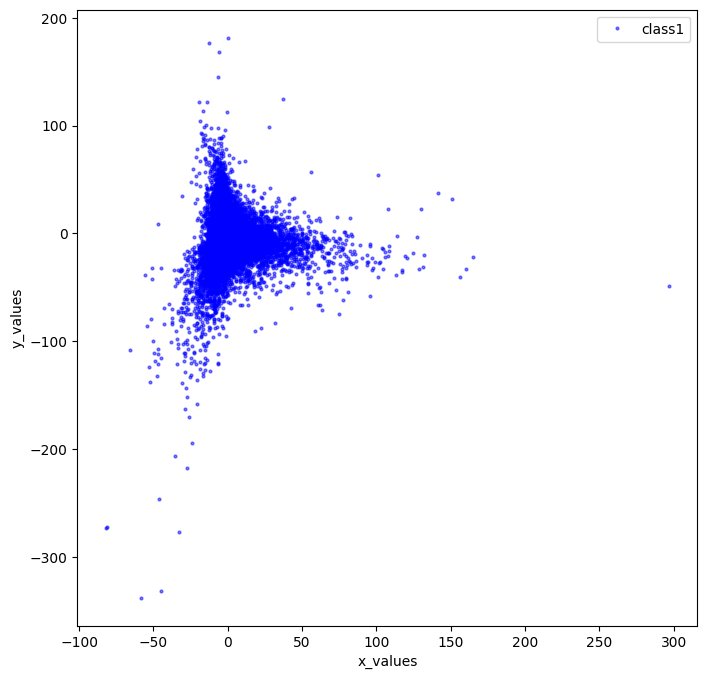

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
tocluster = pd.DataFrame(ps[[4,1]])
print (tocluster.shape)
print (tocluster.head())

fig = plt.figure(figsize=(8,8))
plt.plot(tocluster[4], tocluster[1], 'o', markersize=2, color='blue', alpha=0.5, label='class1')

plt.xlabel('x_values')
plt.ylabel('y_values')
plt.legend()
plt.show()

### Elbow Method

The elbow method examines how inertia changes as the number of clusters increases. Inertia will generally decrease as more clusters are added, so we look for a point where the reduction begins to slow substantially.

### Silhouette Score

The silhouette score provides a complementary criterion for selecting K. A higher score indicates that observations are, on average, closer to the observations within their own cluster than to observations belonging to other clusters.

Shape of clustering data: (194319, 2)
Using 10000 observations for the silhouette calculation.
Calculating K = 2...
Calculating K = 3...
Calculating K = 4...
Calculating K = 5...
Calculating K = 6...
Calculating K = 7...
Calculating K = 8...


,K,Inertia,Silhouette Score
0,2,1.236896e+07,0.738666
1,3,9.492082e+06,0.677215
2,4,7.608478e+06,0.684053
3,5,6.037921e+06,0.644376
4,6,5.111122e+06,0.558854
5,7,4.388227e+06,0.553177
6,8,3.846590e+06,0.562421


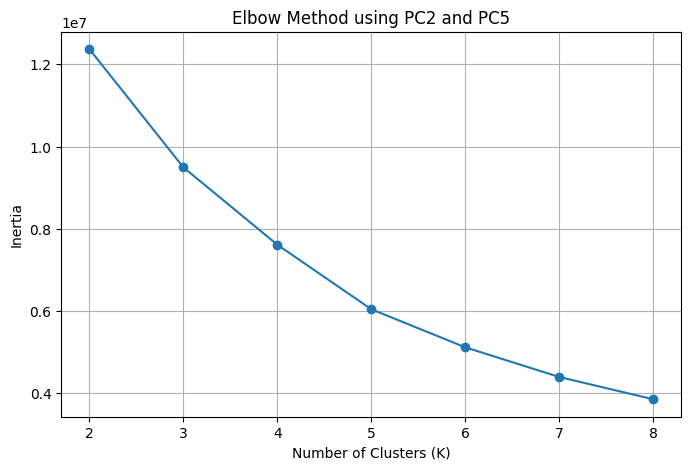

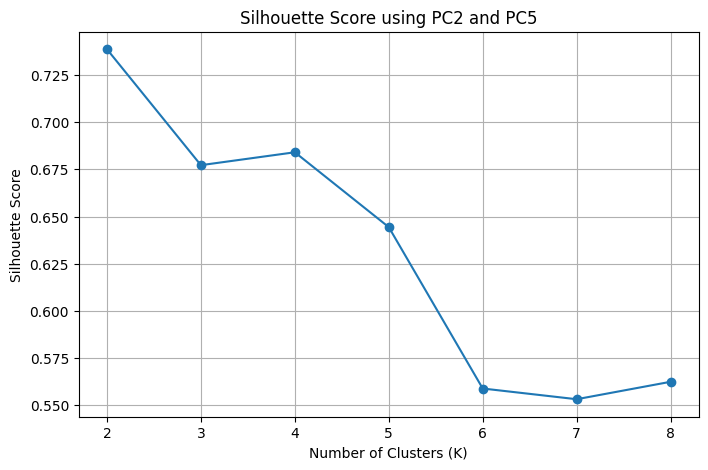

Highest silhouette score occurs at K = 2
Silhouette score = 0.7387


In [ ]:
# ============================================================
# STEP 1: Create the dataset using ONLY PC2 and PC5
# ============================================================

tocluster = ps[[1, 4]].copy()
tocluster.columns = ['PC2', 'PC5']

print("Shape of clustering data:", tocluster.shape)


# ============================================================
# STEP 2: Choose a sample for the silhouette calculation
# ============================================================

# Use at most 10,000 observations for the silhouette score
sample_size = min(10000, len(tocluster))

silhouette_sample = tocluster.sample(
    n=sample_size,
    random_state=42
)

print(
    f"Using {sample_size} observations "
    f"for the silhouette calculation."
)


# ============================================================
# STEP 3: Calculate inertia and silhouette score
#         for different values of K
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

k_values = range(2, 9)

inertia = []
silhouette_scores = []

for k in k_values:

    print(f"Calculating K = {k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit K-means on the FULL dataset
    labels = kmeans.fit_predict(tocluster)

    # Inertia from the full dataset
    inertia.append(kmeans.inertia_)

    # Predict cluster labels for the silhouette sample
    silhouette_labels = kmeans.predict(silhouette_sample)

    # Silhouette calculated only on the sample
    score = silhouette_score(
        silhouette_sample,
        silhouette_labels
    )

    silhouette_scores.append(score)


# ============================================================
# STEP 4: Create results table
# ============================================================

k_results = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})

display(k_results)


# ============================================================
# STEP 5: Elbow plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method using PC2 and PC5')
plt.xticks(k_values)
plt.grid(True)

plt.show()


# ============================================================
# STEP 6: Silhouette score plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score using PC2 and PC5')
plt.xticks(k_values)
plt.grid(True)

plt.show()


# ============================================================
# STEP 7: Find the K with the highest silhouette score
# ============================================================

best_k = k_values[np.argmax(silhouette_scores)]

print(
    f"Highest silhouette score occurs at K = {best_k}"
)

print(
    f"Silhouette score = "
    f"{max(silhouette_scores):.4f}"
)

The elbow plot provides one indication of a suitable number of clusters by identifying where adding further clusters produces diminishing reductions in within-cluster variation.

For computational efficiency, the silhouette score is calculated using a fixed random sample of up to 10,000 observations, while the K-Means models themselves are fitted using the full dataset.

The evaluation of K provides evidence on the trade-off between cluster compactness and separation. Although K = 2 achieves the highest silhouette score, K = 4 is retained for the final segmentation to obtain a more detailed division of customers into distinct purchasing profiles.

## Final K-Means Customer Segmentation

We now fit the final K-Means model using four clusters. Each customer is assigned to the cluster whose centroid is closest to the customer's position in the PC2–PC5 space.

The resulting clusters represent groups of customers with similar purchasing profiles along the selected principal-component dimensions.

### Cluster Centres

The cluster centres represent the average position of each customer segment in the selected principal-component space. Comparing these centres helps identify how the segments differ in their purchasing behaviour.

### Visualising the Customer Segments

The following plot shows the four customer clusters in the PC2–PC5 space. Each point represents a customer, while the different groups indicate the customer segment assigned by K-Means.

Cluster centers:
[[ 15.7651719   -1.5993423 ]
 [ -0.06246481  -0.05392251]
 [-24.29491357  -4.00882517]
 [-10.73784911  34.12239014]]
First 10 cluster colors:
['blue', 'purple', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'orange']


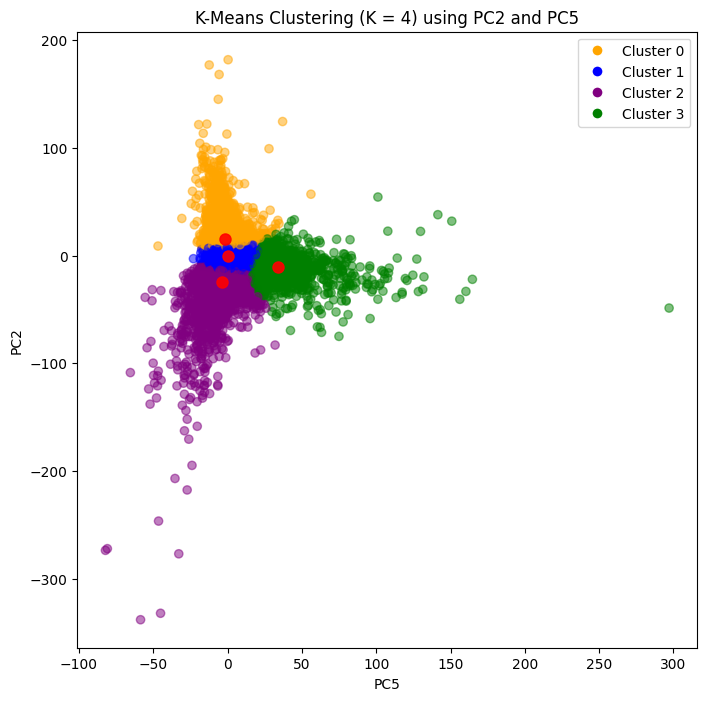

In [ ]:
# ============================================================
# K-MEANS CLUSTERING AND VISUALIZATION FOR K = 4
# ============================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# STEP 1: Fit K-means with K = 4
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

c_preds = kmeans.fit_predict(tocluster)

# Cluster centers
centers = kmeans.cluster_centers_

print("Cluster centers:")
print(centers)


# ------------------------------------------------------------
# STEP 2: Assign a color to each cluster
# ------------------------------------------------------------

colors = ['orange', 'blue', 'purple', 'green']

colored = [colors[k] for k in c_preds]

print("First 10 cluster colors:")
print(colored[:10])


# ------------------------------------------------------------
# STEP 3: Plot the clusters
# ------------------------------------------------------------

%matplotlib inline

fig = plt.figure(figsize=(8, 8))

plt.scatter(
    tocluster['PC5'],
    tocluster['PC2'],
    color=colored,
    alpha=0.5
)


# ------------------------------------------------------------
# STEP 4: Plot the cluster centers
# ------------------------------------------------------------

for ci, c in enumerate(centers):

    plt.plot(
        c[1],       # PC5 coordinate
        c[0],       # PC2 coordinate
        'o',
        markersize=8,
        color='red',
        alpha=0.9
    )


# ------------------------------------------------------------
# STEP 5: Create a correct legend for the clusters
# ------------------------------------------------------------

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Cluster ' + str(i),
        markerfacecolor=colors[i],
        markersize=8
    )
    for i in range(4)
]

plt.legend(handles=legend_elements)


# ------------------------------------------------------------
# STEP 6: Labels and display
# ------------------------------------------------------------

plt.xlabel('PC5')
plt.ylabel('PC2')
plt.title('K-Means Clustering (K = 4) using PC2 and PC5')

plt.show()

## Examining the Purchasing Behaviour of Each Cluster

After assigning each customer to a cluster, we add the cluster label to the original customer-aisle purchasing matrix. This allows us to compare the average purchasing behaviour of customers across the different segments.

In [ ]:
clust_prod = cust_prod.copy()
clust_prod['cluster'] = c_preds

clust_prod.head(10)

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,14,2
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
5,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
8,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,0,0,0,0,5,0,2,0,0,0,...,0,0,0,0,0,0,0,0,5,1


In [ ]:
print (clust_prod.shape)

(194319, 135)


### Comparing Cluster Profiles

We calculate the average purchasing activity for each aisle within each cluster. These averages provide a profile of the typical purchasing behaviour associated with each customer segment.

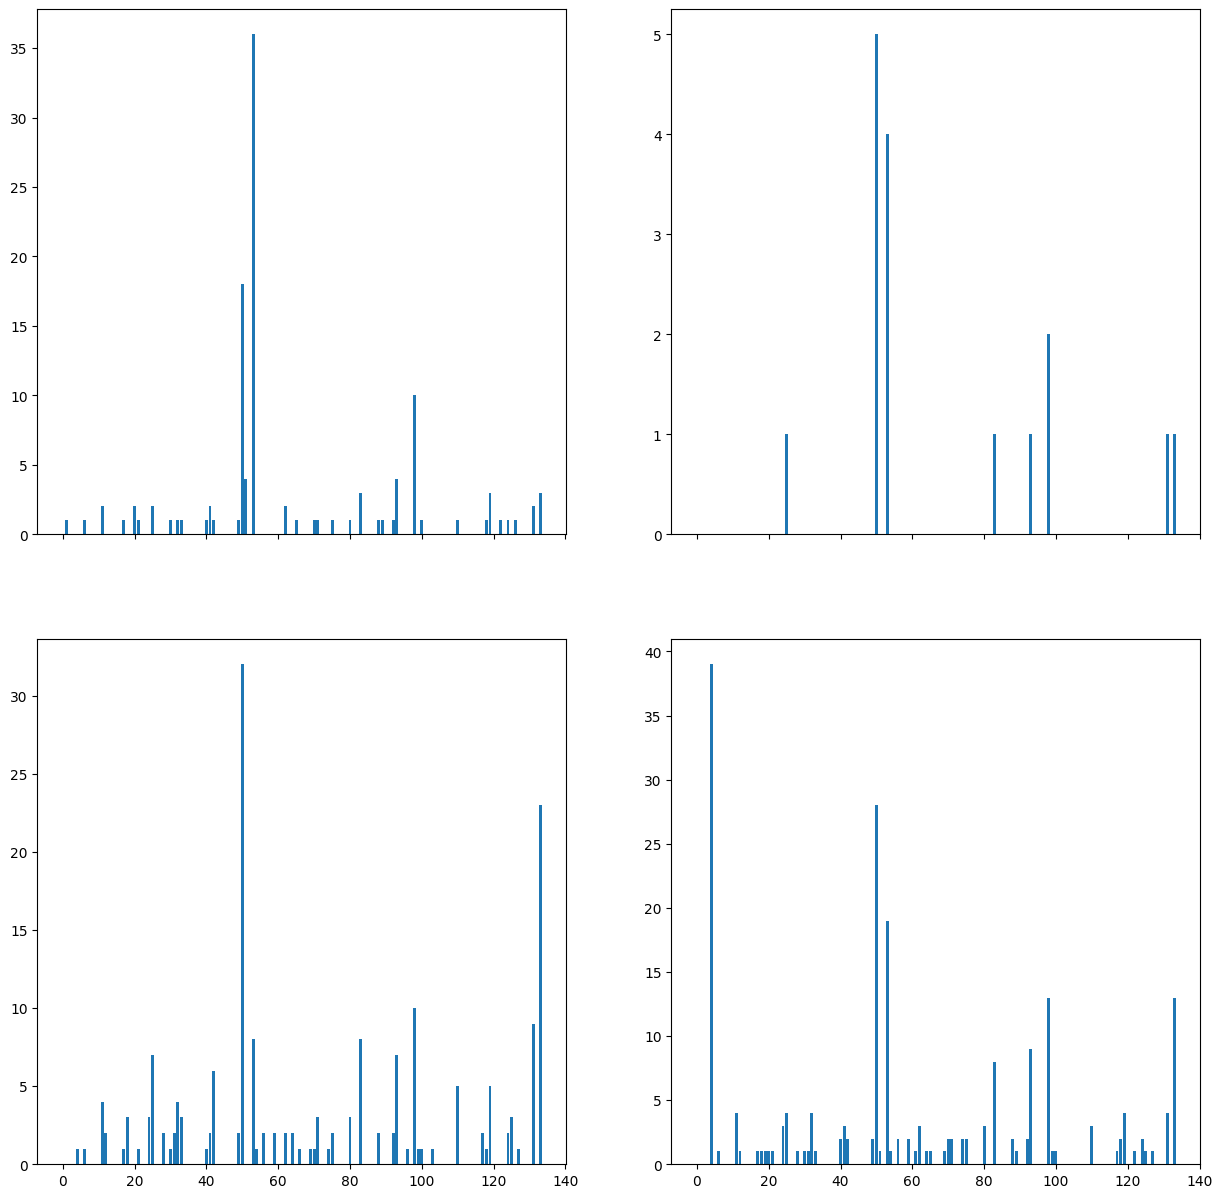

In [ ]:
%matplotlib inline
f,arr = plt.subplots(2,2,sharex=True,figsize=(15,15))

c1_count = len(clust_prod[clust_prod['cluster']==0])

c0 = clust_prod[clust_prod['cluster']==0].drop('cluster',axis=1).mean()
arr[0,0].bar(range(len(clust_prod.drop('cluster',axis=1).columns)),c0)

c1 = clust_prod[clust_prod['cluster']==1].drop('cluster',axis=1).mean()
arr[0,1].bar(range(len(clust_prod.drop('cluster',axis=1).columns)),c1)

c2 = clust_prod[clust_prod['cluster']==2].drop('cluster',axis=1).mean()
arr[1,0].bar(range(len(clust_prod.drop('cluster',axis=1).columns)),c2)

c3 = clust_prod[clust_prod['cluster']==3].drop('cluster',axis=1).mean()
arr[1,1].bar(range(len(clust_prod.drop('cluster',axis=1).columns)),c3)
plt.show()

The cluster profiles allow us to compare the purchasing patterns of the different customer segments and identify the aisles that distinguish one segment from another.

In [ ]:
c0.sort_values(ascending=False)[0:10]

,0
aisle,
fresh vegetables,36
fresh fruits,18
packaged vegetables fruits,10
fresh herbs,4
packaged cheese,4
milk,3
yogurt,3
soy lactosefree,3
eggs,2


In [ ]:
c1.sort_values(ascending=False)[0:10]

,0
aisle,
fresh fruits,5
fresh vegetables,4
packaged vegetables fruits,2
chips pretzels,1
packaged cheese,1
yogurt,1
milk,1
water seltzer sparkling water,1
bakery desserts,0


In [ ]:
c2.sort_values(ascending=False)[0:10]

,0
aisle,
fresh fruits,32
yogurt,23
packaged vegetables fruits,10
water seltzer sparkling water,9
fresh vegetables,8
milk,8
chips pretzels,7
packaged cheese,7
energy granola bars,6


In [ ]:
c3.sort_values(ascending=False)[0:10]

,0
aisle,
baby food formula,39
fresh fruits,28
fresh vegetables,19
yogurt,13
packaged vegetables fruits,13
packaged cheese,9
milk,8
crackers,4
water seltzer sparkling water,4


In [ ]:
from IPython.display import display, HTML
cluster_means = [[c0['fresh fruits'],c0['fresh vegetables'],c0['packaged vegetables fruits'], c0['yogurt'], c0['packaged cheese'], c0['milk'],c0['water seltzer sparkling water'],c0['chips pretzels']],
                 [c1['fresh fruits'],c1['fresh vegetables'],c1['packaged vegetables fruits'], c1['yogurt'], c1['packaged cheese'], c1['milk'],c1['water seltzer sparkling water'],c1['chips pretzels']],
                 [c2['fresh fruits'],c2['fresh vegetables'],c2['packaged vegetables fruits'], c2['yogurt'], c2['packaged cheese'], c2['milk'],c2['water seltzer sparkling water'],c2['chips pretzels']],
                 [c3['fresh fruits'],c3['fresh vegetables'],c3['packaged vegetables fruits'], c3['yogurt'], c3['packaged cheese'], c3['milk'],c3['water seltzer sparkling water'],c3['chips pretzels']]]
cluster_means = pd.DataFrame(cluster_means, columns = ['fresh fruits','fresh vegetables','packaged vegetables fruits','yogurt','packaged cheese','milk','water seltzer sparkling water','chips pretzels'])
HTML(cluster_means.to_html())

,fresh fruits,fresh vegetables,packaged vegetables fruits,yogurt,packaged cheese,milk,water seltzer sparkling water,chips pretzels
0,18,36,10,3,4,3,2,2
1,5,4,2,1,1,1,1,1
2,32,8,10,23,7,8,9,7
3,28,19,13,13,9,8,4,4


In [ ]:
cluster_perc = cluster_means.iloc[:, :].apply(lambda x: (x / x.sum())*100,axis=1)
HTML(cluster_perc.to_html())

,fresh fruits,fresh vegetables,packaged vegetables fruits,yogurt,packaged cheese,milk,water seltzer sparkling water,chips pretzels
0,23.076923,46.153846,12.820513,3.846154,5.128205,3.846154,2.564103,2.564103
1,31.250000,25.000000,12.500000,6.250000,6.250000,6.250000,6.250000,6.250000
2,30.769231,7.692308,9.615385,22.115385,6.730769,7.692308,8.653846,6.730769
3,28.571429,19.387755,13.265306,13.265306,9.183673,8.163265,4.081633,4.081633


In [ ]:
c0.sort_values(ascending=False)[10:15]

,0
aisle,
chips pretzels,2
frozen produce,2
water seltzer sparkling water,2
bread,2
ice cream ice,1


In [ ]:
c1.sort_values(ascending=False)[10:15]

,0
aisle,
asian foods,0
air fresheners candles,0
baby bath body care,0
baby accessories,0
bulk dried fruits vegetables,0


In [ ]:
c2.sort_values(ascending=False)[10:15]

,0
aisle,
soy lactosefree,5
crackers,4
bread,4
cream,3
ice cream ice,3


In [ ]:
c3.sort_values(ascending=False)[10:15]

,0
aisle,
bread,4
soy lactosefree,4
lunch meat,3
refrigerated,3
frozen produce,3
